# Домашнее задание «Проблемы качества данных»

## Шаблон для выполнения

### Шаг 1. Первичный анализ (EDA)

1. Загрузите файл `orders_dirty.csv`. Проведите беглый осмотр данных:

 - Оцените размер таблицы и типы данных.
 - Найдите топ-3 столбца с наибольшим количеством пропусков.
 - Посмотрите уникальные значения в столбцах `payment_method` и `currency`. Есть ли там странные значения?
 - Проверьте, есть ли дубликаты строк по идентификатору заказа.

*В ноутбуке: выведите 2–3 таблицы/графика и напишите краткий вывод (что бросилось в глаза).*

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Загрузите данные и проведите первичный анализ
df = pd.read_csv('orders_dirty.csv')
df.head()

,row_id,order_id,customer_id,order_date,delivery_date,status,payment_method,currency,price,quantity,total_amount,channel
0,2211,ORD102211,C79689,2025-08-04,2025-08-05,delivered,paypal,EUR,47.42,4.0,189.68,web
1,2136,ORD102136,C59002,2025-08-25,2025-08-31,delivered,credit_card,EUR,39.94,3.0,119.82,app
2,1178,ORD101178,C33324,2025-01-28,2025-02-04,delivered,credit_card,EUR,29.06,NaN,116.24,web
3,1910,ORD101910,C16688,2024-03-29,2024-04-05,delivered,paypal,EUR,47.86,4.0,191.44,web
4,649,ORD100649,C86369,2024-03-20,2024-03-26,delivered,credit_card,EUR,9.31,5.0,46.55,web


In [ ]:
# размер датасета и типы данных в столбцах
print(f'Размер датасета: {df.shape}')
print('\nТипы данных в столбцах:')
print(df.dtypes)

# топ-3 столбцов с самым большим количеством пропусков
print('\nСтолбцы с наибольшим количеством пропусков:')
print(df.isna().sum().sort_values(ascending=False).head(3))

# уникальные значения в категориальных столбцах
print('\nУникальные значения категориальных столбцов:')
print(f'payment_method - {df['payment_method'].astype(str).unique()}')
print(f'currency - {df['currency'].astype(str).unique()}')
print(f'status - {df['status'].astype(str).unique()}')
print(f'channel - {df['channel'].astype(str).unique()}')

Размер датасета: (2570, 12)

Типы данных в столбцах:
row_id              int64
order_id           object
customer_id        object
order_date         object
delivery_date      object
status             object
payment_method     object
currency           object
price             float64
quantity          float64
total_amount      float64
channel            object
dtype: object

Столбцы с наибольшим количеством пропусков:
order_id          20
customer_id       20
payment_method    15
dtype: int64

Уникальные значения категориальных столбцов:
payment_method - ['paypal' 'credit_card' 'cash' 'card' 'crypto' 'nan' 'apple_pay']
currency - ['EUR' 'USD']
status - ['delivered' 'processing' 'nan' 'shipped' 'done' 'cancelled' 'x_cancel'
 'in_progress']
channel - ['web' 'app' 'partner']


In [ ]:
# проверка на корректность названий столбцов (отсутствие лишних пробелов)
df.columns

Index(['row_id', 'order_id', 'customer_id', 'order_date', 'delivery_date',
       'status', 'payment_method', 'currency', 'price', 'quantity',
       'total_amount', 'channel'],
      dtype='object')

In [ ]:
# проверка на дубликаты по идентификатору заказа
order_id_duplicates = df[df['order_id'].duplicated(keep='first')]
order_id_duplicates

,row_id,order_id,customer_id,order_date,delivery_date,status,payment_method,currency,price,quantity,total_amount,channel
245,1525,ORD101525,C14263,2024-04-12,2024-04-15,processing,cash,EUR,57.62,1.0,57.62,partner
256,1935,ORD101935,C24721,2025-11-10,2025-11-17,delivered,paypal,EUR,38.94,4.0,155.76,web
262,251,ORD100251,C54458,2024-02-29,2024-03-07,shipped,credit_card,EUR,26.52,1.0,26.52,web
469,149,NaN,C15247,2024-08-29,2024-09-02,cancelled,credit_card,EUR,23.27,3.0,69.81,web
531,2356,ORD102356,C47042,2025-09-10,2025-09-11,delivered,paypal,EUR,31.23,2.0,62.46,web
...,...,...,...,...,...,...,...,...,...,...,...,...
2433,2507,ORD100941,C46362,2024-01-18,2024-01-22,delivered,credit_card,EUR,32.79,2.0,65.58,app
2434,2524,ORD101074,C52004,2025-11-27,2025-12-03,delivered,paypal,USD,19.86,1.0,19.86,web
2446,1757,ORD101757,C64786,2024-03-06,2024-03-12,delivered,cash,USD,56.18,2.0,112.36,app
2466,804,ORD100804,C76439,2024-03-27,2024-04-02,shipped,credit_card,EUR,32.16,5.0,160.80,partner


In [ ]:
print(f'Число строк с отрицательной ценой: {len(df[df['price'] < 0])}')
print(f'Число строк с отрицательным количеством: {len(df[df['quantity'] < 0])}')
print(f'Число строк с отрицательной суммой: {len(df[df['total_amount'] < 0])}')

Число строк с отрицательной ценой: 28
Число строк с отрицательным количеством: 10
Число строк с отрицательной суммой: 0


In [ ]:
# преобразование дат
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

# проверка корректности сессий
incorrect_dates = df[df['delivery_date'] < df['order_date']]
print(incorrect_dates)

# проверки на пропуски в датах
print(f'\nПропуски в датах заказа: {df['order_date'].isna().sum()}')
print(f'Пропуски в датах доставки: {df['delivery_date'].isna().sum()}')

Empty DataFrame
Columns: [row_id, order_id, customer_id, order_date, delivery_date, status, payment_method, currency, price, quantity, total_amount, channel]
Index: []

Пропуски в датах заказа: 10
Пропуски в датах доставки: 0


***Краткий вывод по первичному анализу:***
1.   Типы данных столбцов в целом соответствуют данным
2.   Часть столбцов имеют пропуски
3.   Названия всех столбцов корректны
4.   Есть странные значения (ошибки категорий) в столбцах `payment_method`, `status`
5.   Есть дубликаты строк по идентификатору заказа
6.   Есть строки с нарушениями диапазонов
7.   Даты заказов корректны в той части, что нет дат доставки ранее даты заказа

### Шаг 2. Реализация детекторов

Вам нужно реализовать 4 функции-детектора. Каждая функция должна возвращать список найденных проблем в формате кортежа: `(индекс_строки, название_колонки, тип_ошибки)`.

**Бизнес-правила для проверки:**

1. **Пропуски (`missing`):** любое значение `NaN` в данных недопустимо.
2. **Дубликаты (`duplicate_row`):** один `order_id` должен встречаться только один раз. Повторы считаются ошибкой.
3. **Нарушения диапазонов (`range_violation`):**
    - Цена (`price`) и количество (`quantity`) не могут быть отрицательными или равными нулю.
4. **Ошибки категорий (`category_inconsistency`):**
    - Статус заказа может быть только: `delivered`, `shipped`, `cancelled`, `processing`.
    - Метод оплаты может быть только: `credit_card`, `paypal`, `cash`.
    - Любые другие значения (включая опечатки, разный регистр) считаются ошибкой.

*Подсказка: используйте множества (set) или списки допустимых значений (whitelist) для проверки категорий.*

In [ ]:
# допустимые значения категориальных столбцов
allowed_pay_methods = {'credit_card', 'paypal', 'cash'}
allowed_status = {'delivered', 'shipped', 'cancelled', 'processing'}

In [ ]:
def detect_missing(df):
    """
    Обнаруживает пропущенные значения в датафрейме.
    Выполняет поиск ячеек со значением NaN во всех столбцах
    датафрейма и формирует множество записей о найденных
    нарушениях качества данных.
    Args:
        df (pd.DataFrame): Исходный датафрейм для проверки.
    Returns:
        set[tuple[int, str, str]]: Множество кортежей вида
        (row_id, имя_столбца, 'missing').
    """
    rows, cols = np.where(df.isna())
    return {
        (df.loc[row, 'row_id'], df.columns[col], 'missing')
         for row, col in zip(rows, cols)
         }

def detect_duplicates(df):
    """
    Обнаруживает дублирующиеся заказы по идентификатору order_id.
    Считает дубликатами все повторные вхождения значения
    order_id, кроме первого, и формирует множество записей
    о найденных нарушениях.
    Args:
        df (pd.DataFrame): Исходный датафрейм для проверки.
    Returns:
        set[tuple[int, str, str]]: Множество кортежей вида
        (row_id, 'order_id', 'duplicate_row').
    """
    dup_idx = df.index[df['order_id'].duplicated(keep='first')]
    return {(df.loc[row, 'row_id'], 'order_id', 'duplicate_row') for row in dup_idx}

def detect_range_violations(df):
    """
    Обнаруживает нарушения допустимых диапазонов числовых данных.
    Проверяет корректность значений признаков price и quantity.
    Нарушением считается неположительное значение
    соответствующего признака.
    Args:
        df (pd.DataFrame): Исходный датафрейм для проверки.
    Returns:
        set[tuple[int, str, str]]: Множество кортежей,
        содержащих информацию о найденных нарушениях диапазона.
    """
    range_violations = set()

    price_mask = df['price'] <= 0
    range_violations.update(
        {(df.loc[row, 'row_id'], 'price', 'range_violation')
         for row in df.index[price_mask]}
        )

    qty_mask = df['quantity'] <= 0
    range_violations.update(
        {(df.loc[row, 'row_id'], 'quantity', 'range_violation')
         for row in df.index[qty_mask]}
        )

    return range_violations

def detect_category_inconsistency(df):
    """
    Обнаруживает некорректные значения категориальных признаков.
    Проверяет принадлежность значений столбцов payment_method
    и status заранее определённым допустимым категориям и
    формирует множество записей о найденных несоответствиях.
    Args:
        df (pd.DataFrame): Исходный датафрейм для проверки.
    Returns:
        set[tuple[int, str, str]]: Множество кортежей,
        содержащих информацию о категориальных несоответствиях.
    """
    category_inconsistency = set()

    pay_methods_mask = ~df['payment_method'].isin(allowed_pay_methods)
    category_inconsistency.update(
        {(df.loc[row, 'row_id'], 'payment_method', 'category_inconsistency')
         for row in df.index[pay_methods_mask]}
        )

    status_mask = ~df['status'].isin(allowed_status)
    category_inconsistency.update(
        {(df.loc[row, 'row_id'], 'status', 'category_inconsistency')
         for row in df.index[status_mask]}
        )

    return category_inconsistency


In [ ]:
# запуск всех детекторов
detected_set = set().union(
    detect_missing(df),
    detect_duplicates(df),
    detect_range_violations(df),
    detect_category_inconsistency(df)
)

# перевод в DataFrame
detected_df = pd.DataFrame(
    list(detected_set),
    columns=['row_id', 'column', 'issue_type']
    )

# количество найденных проблем по типам
detected_df['issue_type'].value_counts()

,count
issue_type,
category_inconsistency,100
missing,100
duplicate_row,89
range_violation,75


### Шаг 3. Оценка качества поиска

1. Загрузите файл `orders_truth_hidden.csv`. Сравните список ошибок, который нашли ваши детекторы, с эталонным списком.
2. Рассчитайте метрику **Recall** по формуле:

$$ Recall = \frac{TP}{TP + FN} $$

где:
- **TP (True Positive)**: количество совпавших ошибок (найденных вами и существующих в эталоне).
- **TP + FN**: общее количество ошибок в файле truth.

**Цель:** получить общий Recall не ниже 80%.

In [ ]:
df_truth = pd.read_csv('orders_truth_hidden.csv')
print(df_truth)

     row_id    column     issue_type
0       622  order_id        missing
1      1946  order_id        missing
2      1535  order_id        missing
3       228  order_id        missing
4       125  order_id        missing
..      ...       ...            ...
380    2565  order_id  duplicate_row
381    2566  order_id  duplicate_row
382    2567  order_id  duplicate_row
383    2568  order_id  duplicate_row
384    2569  order_id  duplicate_row

[385 rows x 3 columns]


In [ ]:
# расчет Recall
recall = len(detected_df) / len(df_truth)

print(f'Найдено проблем (TP): {len(detected_df)}')
print(f'Всего истинных проблем (TP+FN): {len(df_truth)}')
print(f'Recall: {recall:.2%}')

Найдено проблем (TP): 364
Всего истинных проблем (TP+FN): 385
Recall: 94.55%


### Шаг 4. Очистка и Моделирование

Докажите бизнесу, что чистка данных имеет смысл.

1. **Напишите функцию очистки:**
    - Удалите дубликаты.
    - Заполните пропуски (например, медианой для чисел и модой для категорий).
    - Исправьте опечатки в категориях (приведите к нижнему регистру, устраните неявные дубликаты).
    - Обработайте некорректные числовые значения (например, возьмите модуль от отрицательной цены).

2. **Обучите модель:**
    - Подготовьте данные: целевая метка формируется из `status`: `target=1`, если `status='cancelled'`, иначе `0`.
    - Обучите простую `LogisticRegression` дважды: на «грязных» данных и на очищенных.
    - Сравните метрику `Accuracy`.

In [ ]:
# функция очистки данных
def clean_data(df):
    """
    Выполняет очистку и подготовку данных для дальнейшего анализа и
    моделирования.
    Удаляет дублирующиеся записи по order_id, нормализует значения
    категориальных признаков,
    обрабатывает некорректные значения, заполняет пропуски и возвращает
    очищенный датафрейм. Для числовых признаков пропуски заполняются медианой,
    для категориальных — наиболее частым значением, а пропуски в дате заказа —
    соответствующей датой доставки.
    Args:
        df (pd.DataFrame): Исходный датафрейм с неочищенными данными.
    Returns:
        pd.DataFrame: Копия датафрейма после выполнения всех этапов очистки
        и предобработки данных.
    """
    clean_df = df.copy()

    # 1) удаление дубликатов
    clean_df = clean_df.drop_duplicates(keep='first').reset_index(drop=True)

    # 2) чистка и нормализация категорий
    pay_cat_map =  {
        'card' : 'credit_card',
        'crypto': 'credit_card',
        'apple_pay' : 'credit_card'
        }

    clean_df['payment_method'] = clean_df['payment_method'].replace(pay_cat_map)
    clean_df.loc[
        ~clean_df['payment_method'].isin(allowed_pay_methods), 'payment_method'
        ] = np.nan
    clean_df['payment_method'] = clean_df[
        'payment_method'
        ].fillna(clean_df['payment_method'].mode()[0])

    status_cat_map =  {
        'done' : 'delivered',
        'in_progress': 'processing',
        'x_cancel' : 'cancelled'
        }

    clean_df['status'] = clean_df['status'].replace(status_cat_map)
    clean_df.loc[~clean_df['status'].isin(allowed_status), 'status'] = np.nan
    clean_df['status'] = clean_df['status'].fillna(clean_df['status'].mode()[0])

    # 3) заполнение NaN некорректных диапазонов
    clean_df.loc[clean_df['price'] <= 0, 'price'] = np.nan
    clean_df.loc[clean_df['quantity'] <= 0, 'quantity'] = np.nan

    # 4.1) заполнение числовых пропусков медианой
    num_cols = clean_df.select_dtypes(include='number').columns.tolist()
    clean_df[num_cols] = clean_df[num_cols].fillna(clean_df[num_cols].median())

    # 4.2) заполнение строковых пропусков первой модой
    cat_cols = clean_df.select_dtypes(include='object').columns.tolist()
    clean_df[cat_cols] = clean_df[cat_cols].fillna(
        clean_df[cat_cols].mode().iloc[0]
        )

    # 4.3) заполнение пропусков дат заказа датами доставки (в них нет пропусков)
    clean_df['order_date'] = clean_df['order_date'].fillna(
        clean_df['delivery_date']
        )

    return clean_df

In [ ]:
# чистка
clean_df_train = clean_data(df)

# быстрые проверки после очистки
post_check = {
    'rows' : len(clean_df_train),
    'missing_total' : int(clean_df_train.isna().sum().sum()),
    'duplicate_rows' : int(clean_df_train.duplicated().sum()),
    'range_violations_price' : int((clean_df_train['price'] <= 0).sum()),
    'range_violations_quantity' : int((clean_df_train['quantity'] <= 0).sum()),
    'bad_categories_payment_method' :
    int((~clean_df_train['payment_method'].isin(allowed_pay_methods)).sum()),
    'bad_categories_status' :
    int((~clean_df_train['status'].isin(allowed_status)).sum())
}
pd.Series(post_check)

,0
rows,2570
missing_total,0
duplicate_rows,0
range_violations_price,0
range_violations_quantity,0
bad_categories_payment_method,0
bad_categories_status,0


In [ ]:
# подготовка данных для обучения

# cоздание целевой метки в датафреймах
df['target'] = (df['status'] == 'cancelled').astype(int)
clean_df_train['target'] = (clean_df_train['status'] == 'cancelled').astype(int)

In [ ]:
def get_accuracy(df):
    """
    Оценивает качество модели логистической регрессии на переданном наборе
    данных.
    Разделяет данные на обучающую и тестовую выборки, выполняет частотное
    кодирование категориальных и временных признаков, обрабатывает пропущенные
    значения, обучает модель и вычисляет точность классификации на тестовой
    выборке.
    Args:
        df (pd.DataFrame): Датафрейм, содержащий признаки и целевую
        переменную target.
    Returns:
        float: Значение метрики accuracy, рассчитанное на тестовой
        выборке после обучения модели.
    """
    data = df.copy()

    X = data.drop('target', axis=1)
    y = data['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    cat_cols = X_train.select_dtypes(
        include=['object', 'datetime']
        ).columns.tolist()
    for col in cat_cols:
        freq = X_train[col].value_counts(normalize=True)
        X_train[col + '_freq'] = X_train[col].map(freq).fillna(0)
        X_test[col + '_freq'] = X_test[col].map(freq).fillna(0)
        X_train.drop(col, axis=1, inplace=True)
        X_test.drop(col, axis=1, inplace=True)

    X_train = X_train.fillna(-1)
    X_test = X_test.fillna(-1)

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=5000, random_state=42)
    )
    model.fit(X_train, y_train)

    return accuracy_score(y_test, model.predict(X_test))

accuracy_dirty = get_accuracy(df)
accuracy_clean = get_accuracy(clean_df_train)

print(f'Точность на грязных данных: {accuracy_dirty:.1%}')
print(f'Точность на очищенных данных: {accuracy_clean:.1%}')
print(f'Прирость качества: {accuracy_clean - accuracy_dirty:+.1%}')

Точность на грязных данных: 82.0%
Точность на очищенных данных: 91.1%
Прирость качества: +9.2%


### Шаг 5. Итоги (рефлексия)

Напишите выводы (5–7 предложений):

1. Какие ошибки было найти сложнее всего?
2. Как сильно выросла точность модели после очистки?
3. Какую **одну** проверку (из реализованных вами) вы бы поставили на ежедневный мониторинг в первую очередь и почему?

**Выводы:**

1.   Сложнее всего было искать категориальные несоответствия ввиду того, что они требуют заранее подготовленного набора допустимых значений, причем исходя из логики данных. Однако в данной работе поиск все же был упрощен, так как набор допустимых значений был уже подготовлен.
2.   Точность модели после очистки данных выросла более чем на 10%, превысив в итоге 91%. Такой прирост показывает, что качество данных существенно влияет на точность модели, качество ее обучения, и подтверждает необходимость предварительной очистки данных перед обучением.
*При этом, хочу добавить, что изначально модель обучалась только на числовых признаках, и очистка данных не повлияла на ее точность. Вероятно, это связано с небольшой долей ошибок в числовых столбцах и их малой информативностью. После же я применил frequency encoding для категориальных столбцов, и был получен указанный прирост точности.*
3.   В первую очередь я поставил бы на ежедневный мониторинг проверку на дубликаты по order_id. Такие дубликаты приводят к повторному учету одних и тех же заказов, что серьезно искажает статистику и ухудшает данные для обучения модели. При этом проверка проста в реализации.





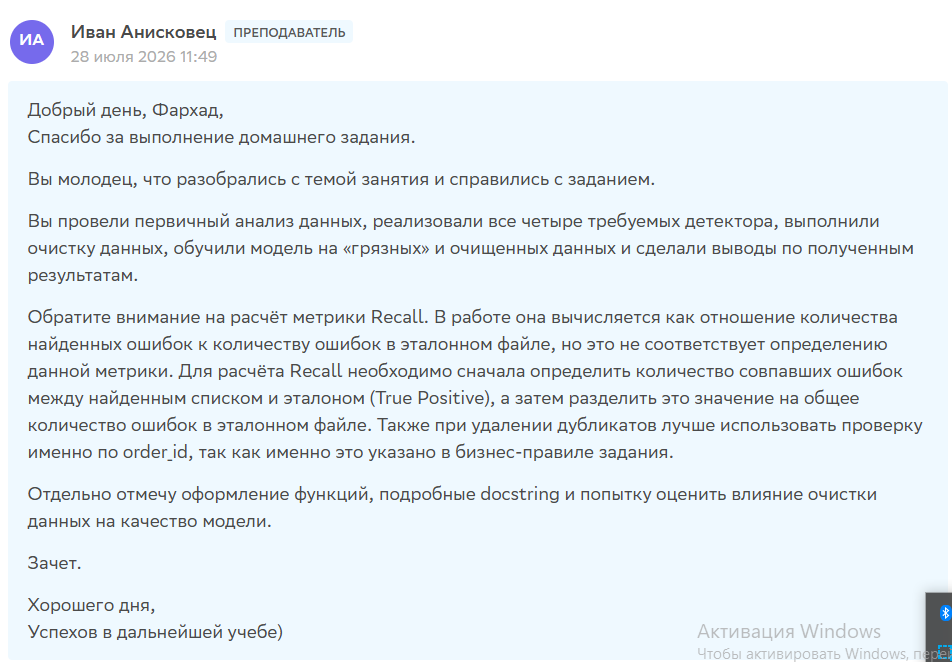

In [ ]:
# формируем множества «истина» и «нашли»
true_set = set(df_truth.itertuples(index=False, name=None))
found_set = set(detected_df.itertuples(index=False, name=None))

In [ ]:
# расчет TP и Recall

tp_set = true_set & found_set
recall = len(tp_set) / len(true_set)

print(f'Найдено корректно проблем (TP): {len(tp_set)}')
print(f'Всего истинных проблем (TP+FN): {len(true_set)}')
print(f'Recall: {recall:.2%}')

Найдено корректно проблем (TP): 315
Всего истинных проблем (TP+FN): 385
Recall: 81.82%
